# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [66]:

# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [67]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [68]:

# mostrar las primeras 5 filas de plans
print("Plans")
display(plans.head())



Plans


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [69]:

# mostrar las primeras 5 filas de users
print("Users")
display(users.head())



Users


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [70]:
# mostrar las primeras 5 filas de usage
print("Usage")
display(usage.head())



Usage


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [71]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [72]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [73]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [74]:
# inspección de usage con .info()
usage.info

<bound method DataFrame.info of           id  user_id  type                           date  duration  length
0          1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1          2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2          3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3          4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4          5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN
...      ...      ...   ...                            ...       ...     ...
39995  39996    13497  call  2024-06-29 23:33:56.120903022      5.75     NaN
39996  39997    10941  call  2024-06-29 23:40:27.090677266      3.06     NaN
39997  39998    13038  call  2024-06-29 23:46:58.060451510      8.74     NaN
39998  39999    10863  text  2024-06-29 23:53:29.030225754       NaN    43.0
39999  40000    10759  call  2024-06-30 00:00:00.000000000      1.32     NaN

[40000 rows x 6 columns]>

🧩Paso 2: Identificación de problemas de calidad de datos

2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [75]:

# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [76]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

**Dataset plans** No presenta valores nulos, por lo que no requiere acciones de limpieza relacionadas con datos faltantes.
**Dataset users**:city (11.73 % de nulos) presenta un porcentaje moderado de valores faltantes. Se recomienda investigar la causa y decidir si imputar los valores o mantenerlos como nulos según el análisis.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? 
- Indica qué harías: ¿imputar, eliminar, ignorar?

**plans**: No presenta valores faltantes, por lo que no requiere ninguna acción.
**users.city**: Tiene 469 valores nulos (11.73 %). Se recomienda investigar la causa y, según el contexto, imputar los valores o mantenerlos como nulos si no afectan el análisis.
**users.churn_date**: Tiene 3,534 valores nulos (88.35 %). Se recomienda ignorar estos nulos, ya que probablemente representan clientes que aún no han cancelado el servicio.
**usage.date**: Tiene 50 valores nulos (0.125 %). Debido a su baja proporción, se recomienda eliminar esos registros o dejarlos como nulos si su impacto en el análisis es mínimo.
**usage.duration**: Tiene 22,076 valores nulos (55.19 %). Se recomienda no imputar ni eliminar, ya que los valores faltantes son esperados para los registros de tipo text.
**usage.length**: Tiene 17,896 valores nulos (44.74 %). Se recomienda no imputar ni eliminar, ya que los valores faltantes son esperados para los registros de tipo call.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [77]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` contiene identificadores únicos de los usuarios. Los valores van de 10000 a 13999 y no se observan valores inválidos.

- La columna `age` presenta un valor mínimo de -999, el cual no corresponde a una edad válida y probablemente representa un sentinel para indicar un dato faltante. Se recomienda reemplazar este valor por NaN antes de continuar con el análisis.

In [78]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`contienen identificadores de los registros y de los usuarios. Sus valores están dentro de los rangos esperados y no se observan valores inválidos.
  
- Las columnas duration y length: No presentan valores negativos. La duración de las llamadas varía entre 0 y 120 minutos, mientras que la longitud de los mensajes varía entre 0 y 1490 caracteres. Aunque no se identifican sentinels, será conveniente revisar los valores más altos en la etapa de detección de valores atípicos (outliers).

In [79]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"\nColumna: {columna}")
    print(users[columna].value_counts(dropna=False))




Columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` contiene varias ciudades válidas, pero también presenta 469 valores nulos y 96 registros con el valor "?", el cual corresponde a un sentinel o valor inválido. Se recomienda reemplazar "?" por NaN para tratar todos los datos faltantes de forma consistente.
- La columna `plan` solo contiene las categorías Basico y Premium, las cuales son válidas y coinciden con los planes definidos en el dataset plans. No se observan valores inválidos.

In [80]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene únicamente las categorías call y text, las cuales son válidas para identificar el tipo de actividad registrada. No se observan valores inválidos, categorías inesperadas ni sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?

**users.age**: Se encontró el valor -999, el cual es un sentinel y no representa una edad válida. Se recomienda reemplazarlo por NaN para tratarlo como un valor faltante.
**users.city**: Se encontraron 96 registros con el valor **"?"**, que corresponde a un valor inválido o sentinel. Se recomienda reemplazar "?" por NaN para unificar el tratamiento de los datos faltantes.
**users.plan**: Solo contiene los valores Basico y Premium, por lo que no presenta valores inválidos.

Columnas numéricas de usage (id, user_id, duration y length): No se identificaron sentinels. Los valores extremos de duration y length se analizarán posteriormente como posibles valores atípicos (outliers).


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [81]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [82]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [83]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, En la columna reg_date se encontraron registros correspondientes a los años 2022, 2023 y 2024, que están dentro del periodo de análisis. Sin embargo, también se identificaron 40 registros del año 2026, el cual está fuera del rango esperado. Se recomienda revisar estos registros y corregirlos o marcarlos como valores inválidos antes de continuar con el análisis.

In [84]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, Todos los registros con fecha válida corresponden al año 2024, que coincide con el periodo de análisis del proyecto. No se identifican años fuera de rango. Los 50 valores faltantes corresponden a fechas ausentes y deberán tratarse durante la limpieza de datos.

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**users.reg_date**: Se encontraron registros de los años 2022, 2023 y 2024, que son válidos para el periodo de análisis. Sin embargo, también se identificaron 40 registros del año 2026, un año posterior al rango esperado. Se recomienda revisar estos registros y corregirlos o marcarlos como valores inválidos (NaT) si no es posible confirmar la fecha correcta.

**usage.date**: Todos los registros con fecha válida corresponden al año 2024, por lo que no se identifican años fuera de rango. Los 50 valores faltantes deberán tratarse durante la limpieza de datos, pero no representan un problema de fechas imposibles.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [85]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [86]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [87]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [88]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [89]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**La columna duration** presenta valores nulos asociados al tipo de actividad (type). Los registros de tipo call no tienen valores faltantes, mientras que los registros de tipo text presentan casi todos los valores nulos porque la duración no aplica para mensajes. Por lo tanto, los valores faltantes siguen un patrón MAR y se recomienda mantenerlos como nulos, sin realizar imputación.

**La columna length** presenta valores faltantes que dependen del tipo de actividad (type). Los registros de llamadas (call) no contienen longitud de mensaje porque esta variable no aplica para ese servicio, mientras que los mensajes (text) tienen valores completos.

Se confirma un patrón MAR (Missing At Random), por lo que se recomienda mantener los valores nulos y no realizar imputación, ya que representan una característica natural del dataset.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [90]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3
)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [91]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [92]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [93]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [94]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

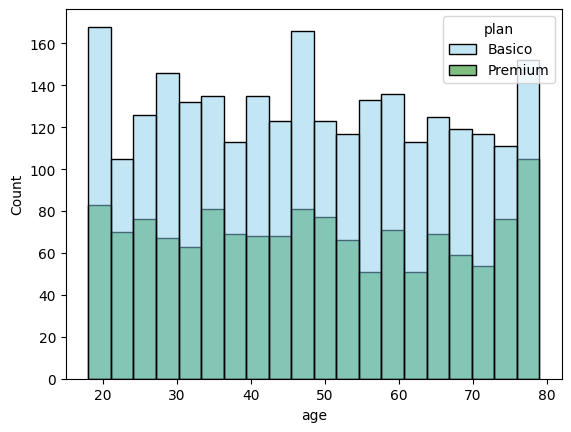

In [95]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20)
plt.show()

💡Insights: 
- Distribución ...Insights:

Distribución de edad (**age**):La distribución de edades es similar entre los usuarios de los planes Básico y Premium. No se observa un patrón claro que relacione una edad específica con la elección del plan.

El plan Básico presenta mayor cantidad de usuarios en todos los rangos de edad debido a que concentra la mayor proporción de clientes. La variable edad presenta una distribución aproximadamente uniforme, con usuarios distribuidos entre 18 y 79 años y sin un sesgo significativo hacia edades jóvenes o mayores.

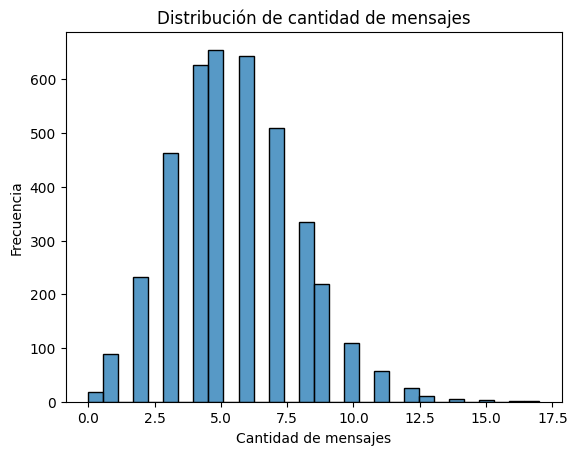

In [100]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile['cant_mensajes'], bins=30)

plt.title("Distribución de cantidad de mensajes")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")

plt.show()

💡Insights: 
- La variable **cant_mensajes** presenta una distribución aproximadamente normal, aunque con una ligera asimetría hacia la derecha.
- La mayor concentración de usuarios se encuentra alrededor de 4 a 7 mensajes, siendo aproximadamente 5 mensajes el valor con mayor frecuencia.
- Existe un grupo reducido de usuarios con valores altos (más de 10 mensajes), llegando hasta cerca de 17 mensajes. Estos podrían representar usuarios más activos o posibles valores extremos.
- La mayoría de los usuarios tienen una cantidad moderada de mensajes, mientras que pocos usuarios muestran una actividad mucho mayor.

La distribución de cant_mensajes muestra que la mayoría de los usuarios tienen entre 4 y 7 mensajes registrados. Se observa una cola hacia la derecha debido a algunos usuarios con una cantidad superior de mensajes, lo que indica la presencia de usuarios con mayor nivel de actividad. No parece haber una gran cantidad de valores atípicos, pero los usuarios con más de 10 mensajes podrían analizarse como un segmento de alta interacción.

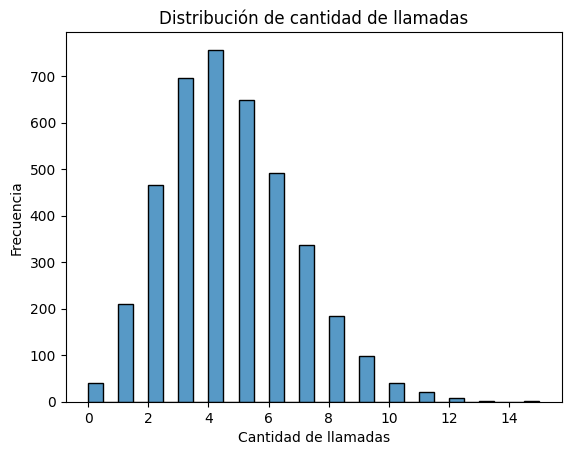

In [101]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile['cant_llamadas'], bins=30)

plt.title("Distribución de cantidad de llamadas")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")

plt.show()

💡Insights: 

-La distribución muestra que la mayor concentración de clientes realiza entre 3 y 5 llamadas, siendo 4 llamadas aproximadamente el valor más frecuente.
-La cantidad de llamadas presenta una distribución sesgada hacia la derecha (asimetría positiva), ya que existen pocos clientes con una cantidad muy alta de llamadas (por encima de 8-10).
-La mayoría de los usuarios tienen un comportamiento de llamadas moderado, mientras que los casos extremos son poco frecuentes.
-Se observan algunos valores altos (alrededor de 12 a 15 llamadas) que podrían considerarse posibles outliers, aunque representan una pequeña proporción de los datos.
-La empresa podría analizar estos clientes con muchas llamadas, ya que podrían indicar problemas recurrentes, mayor necesidad de soporte o posibles oportunidades de mejora en el servicio.

-La distribución indica que el uso habitual del servicio se concentra en pocos contactos por cliente, pero existe un grupo reducido con una alta frecuencia de llamadas que podría requerir un análisis más detallado.

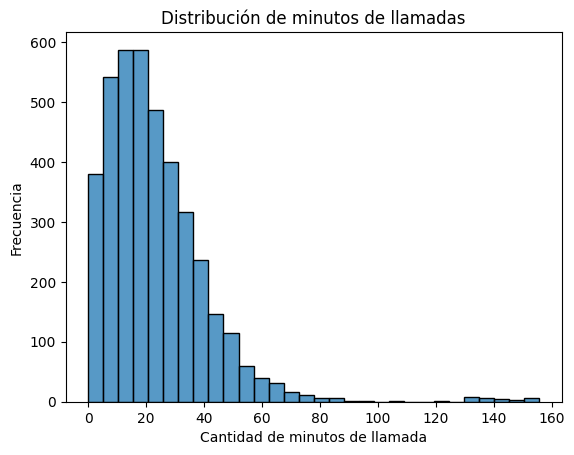

In [106]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", bins=30)

plt.title("Distribución de minutos de llamadas")
plt.xlabel("Cantidad de minutos de llamada")
plt.ylabel("Frecuencia")

plt.show()

💡Insights: 
- La distribución está sesgada hacia la derecha (asimetría positiva).
-La mayoría de los usuarios concentra sus llamadas aproximadamente entre 0 y 40 minutos.
-El rango con mayor frecuencia se encuentra alrededor de 10 a 25 minutos, donde se observa el pico principal.
-Hay pocos usuarios con consumos muy altos, llegando incluso a valores cercanos a 100-160 minutos.
-Estos valores extremos podrían representar usuarios con un uso intensivo de llamadas y conviene revisarlos como posibles outliers.

La mayoría de los clientes realiza llamadas de corta duración, mientras que un grupo reducido presenta un consumo significativamente mayor. La distribución indica que existen usuarios con patrones de uso intensivo que podrían influir en el promedio de minutos de llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

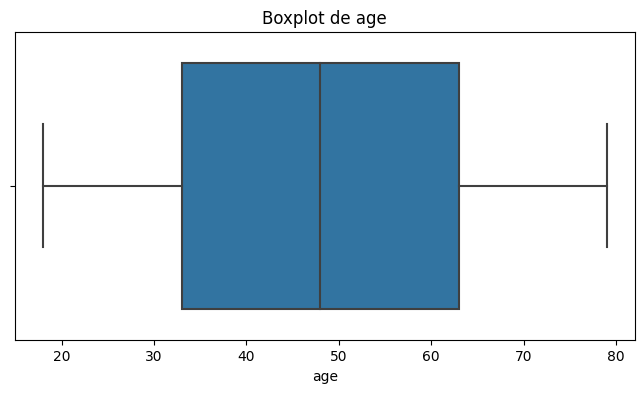

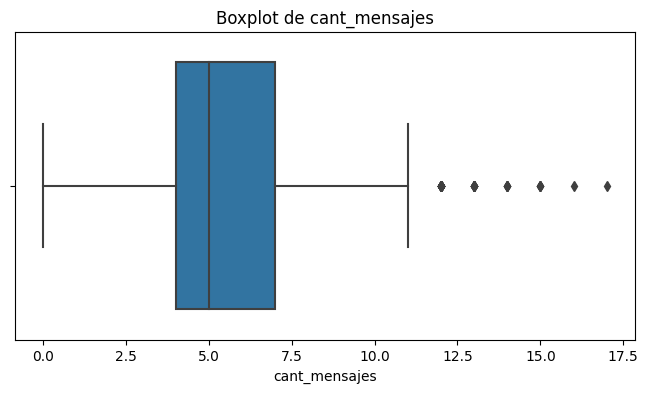

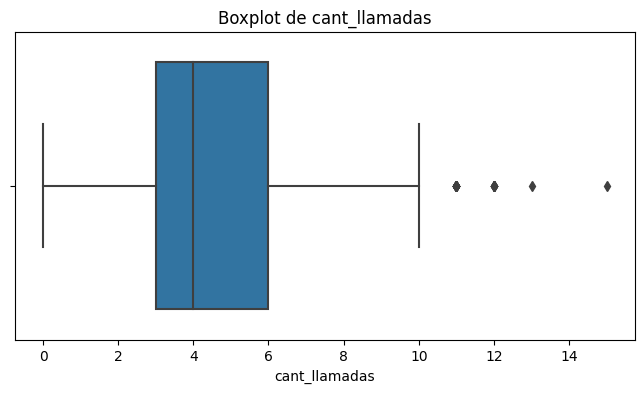

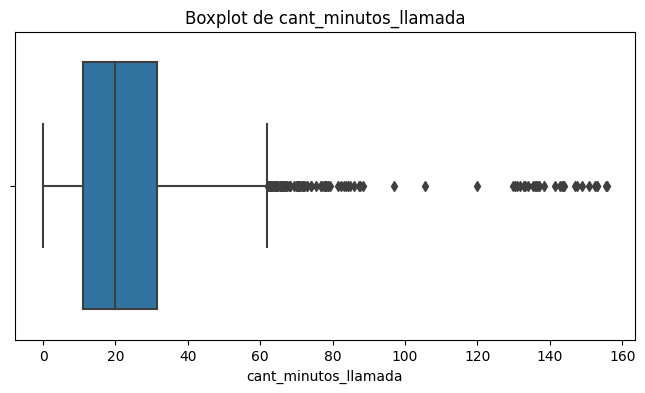

In [108]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=columna)
    plt.title(f'Boxplot de {columna}')
    plt.xlabel(columna)
    plt.show()

💡Insights: 
- **Age**: ...(presenta o no outliers)
-La edad de los clientes presenta una distribución amplia, aproximadamente entre 18 y 79 años, con una concentración importante entre 33 y 63 años. No se detectan valores atípicos que puedan afectar el análisis.
Conlcusión: Age: No presenta outliers. Los valores de edad se encuentran dentro del rango esperado y no se observan puntos fuera de los límites del boxplot, por lo que no se requieren ajustes o limpieza en esta variable.

- **cant_mensajes**: ...
-La variable cant_mensajes presenta outliers (valores atípicos).
-La mayoría de los clientes envían aproximadamente entre 4 y 7 mensajes (rango donde se concentra la caja).
-La mediana está cerca de 5 mensajes, indicando que la mitad de los clientes envía menos de 5 mensajes y la otra mitad más.
-El bigote superior llega aproximadamente hasta 11 mensajes.
-Se observan varios puntos por encima de ese límite (aproximadamente entre 12 y 17 mensajes), los cuales son considerados outliers.
-Estos valores podrían representar clientes con un uso mucho más alto del servicio de mensajería.


Conclusión: cant_mensajes: presenta valores atípicos superiores. Aunque la mayoría de los clientes tienen un consumo moderado de mensajes, existe un grupo pequeño de usuarios con una cantidad significativamente mayor de mensajes enviados. Se recomienda revisar estos casos antes de eliminarlos, ya que podrían corresponder a clientes de alto uso y aportar información relevante para la segmentación.
  
- **cant_llamadas**:
-La variable cant_llamadas presenta outliers superiores.
-La mayor concentración de clientes se encuentra aproximadamente entre 3 y 6 llamadas (zona de la caja).
-La mediana está alrededor de 4 llamadas, lo que indica que la mitad de los clientes realiza menos de 4 llamadas y la otra mitad más.
-El bigote superior llega aproximadamente hasta 10 llamadas.
-Se observan varios puntos por encima de ese límite (alrededor de 11, 12, 13 y 15 llamadas), los cuales son considerados valores atípicos.
-No se observan outliers hacia valores bajos


Conclusión:cant_llamadas presenta valores atípicos en el extremo superior. La mayoría de los clientes realiza una cantidad moderada de llamadas, pero existe un grupo reducido con un uso mucho mayor del servicio. Estos casos deberían revisarse antes de eliminarlos, ya que podrían representar clientes con alta actividad o necesidades particulares de comunicación.

- **cant_minutos_llamada**: ...
- La mediana se encuentra aproximadamente alrededor de 20 minutos, lo que indica que la mitad de los usuarios realiza llamadas con una duración menor o igual a este valor.
-La mayoría de los datos se concentran aproximadamente entre 10 y 32 minutos (rango intercuartílico, IQR).
-El bigote superior llega cerca de 60 minutos, indicando el rango esperado de duración de llamadas sin considerar valores extremos.
-Se observan muchos outliers superiores después de los 60 minutos, llegando incluso a valores cercanos a 160 minutos.
-No se observan outliers inferiores importantes.

Conclusión: cant_minutos_llamada presenta outliers principalmente hacia valores altos. Estos valores representan clientes con tiempos de llamada mucho mayores al comportamiento habitual.
-Los outliers podrían corresponder a usuarios con un uso intensivo del servicio, clientes empresariales o casos particulares.
-Antes de eliminarlos, conviene revisar si son datos reales o errores de registro, ya que podrían aportar información sobre clientes de alto consumo.
-Mantener estos valores si representan usuarios reales; si afectan modelos estadísticos, se podría considerar un tratamiento de outliers.

In [122]:
# Calcular límites con el método IQR
columnas_limites = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

limites_iqr = {}

for columna in columnas_limites:
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    limites_iqr[columna] = {
        'Limite inferior': limite_inferior,
        'Limite superior': limite_superior
    }
tabla_iqr = pd.DataFrame(limites_iqr).T

tabla_iqr = tabla_iqr.round(2)

tabla_iqr



,Limite inferior,Limite superior
age,-12.00,108.00
cant_mensajes,-0.50,11.50
cant_llamadas,-1.50,10.50
cant_minutos_llamada,-19.32,61.86


In [123]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes**: mantener o no outliers, porqué?
Mantener los outliers. Aunque existen valores superiores al límite IQR (11.5 mensajes), el valor máximo es de 17 mensajes, lo cual puede representar usuarios con mayor interacción y no necesariamente errores en los datos. Se recomienda conservarlos para no perder información sobre clientes con alto uso del servicio.
  
- **cant_llamadas: mantener o no outliers, porqué?**
Mantener los outliers. Los valores que superan el límite IQR (10.5 llamadas) alcanzan un máximo de 15 llamadas. Estos casos pueden corresponder a usuarios con una mayor necesidad de comunicación, por lo que eliminarlos podría afectar el análisis del comportamiento real de los clientes.
 
- **cant_minutos_llamada**: mantener o no outliers, porqué?
Mantener los outliers inicialmente. Aunque presenta valores más extremos (límite superior de 61.86 minutos y máximo de 155.69 minutos), estos pueden representar llamadas largas o clientes con un consumo elevado. Antes de eliminarlos, se recomienda validar si corresponden a registros reales o errores de captura.

In [134]:
# cantidad de outliers (mensajes, llamadas y minutos) para que el análisis ejecutivo quede sustentado con datos cuantitativos.
for columna, limites in limites_iqr.items():      
    cantidad = (
        (user_profile[columna] < limites['Limite inferior']) |
        (user_profile[columna] > limites['Limite superior'])
    ).sum()

    print(f"{columna}: {cantidad} outliers")

age: 0 outliers
cant_mensajes: 46 outliers
cant_llamadas: 30 outliers
cant_minutos_llamada: 109 outliers


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [125]:
# Crear columna grupo_uso
def clasificar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [126]:
# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [127]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [128]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

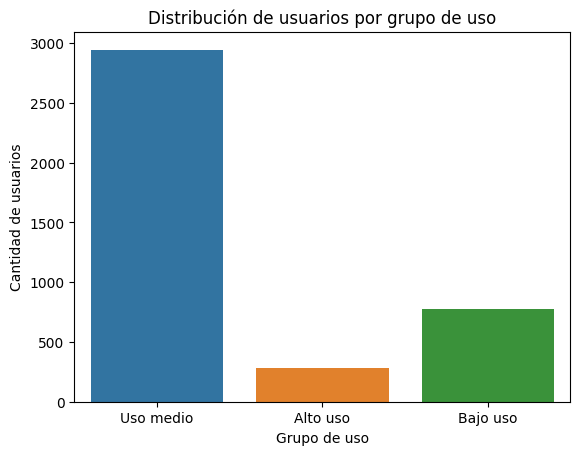

Uso medio    73.58
Bajo uso     19.45
Alto uso      6.98
Name: grupo_uso, dtype: float64

In [132]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()
plt.show()

# agregue porcentaje de usuarios en Uso para tener valores cuantitativos
(user_profile['grupo_uso']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))


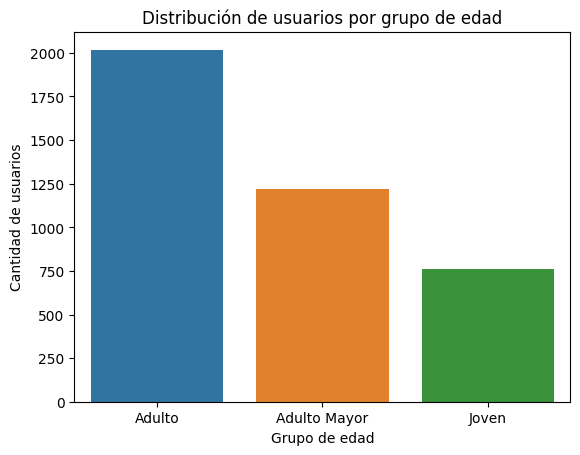

Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64

In [133]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()

# # agregue porcentaje de usuarios en Edad para tener valores cuantitativos
(user_profile['grupo_edad']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-Se identificaron algunos valores faltantes en las variables de uso, los cuales representaban una proporción muy baja del total de registros y no afectaban significativamente el análisis.
-Mediante el método IQR se detectaron 46 outliers en cant_mensajes, 30 outliers en cant_llamadas y 109 outliers en cant_minutos_llamada. La variable age no presentó outliers.
-Tras revisar los valores máximos de cada variable, se concluyó que estos registros corresponden a usuarios con un consumo elevado del servicio y no a errores evidentes, por lo que se decidió conservarlos para el análisis.

🔍 **Segmentos por Edad**

-El 50.45% de los clientes pertenece al grupo Adulto, siendo el segmento más representativo de la base de usuarios.
-El 30.55% corresponde al grupo Adulto Mayor, lo que evidencia una participación importante de clientes de 60 años o más.
-El 19.00% pertenece al grupo Joven, siendo el segmento menos numeroso.

📊 **Segmentos por Nivel de Uso**

-El 73.58% de los clientes pertenece al segmento Uso medio, convirtiéndose en el grupo predominante.
-El 19.45% corresponde al segmento Bajo uso, lo que indica que una parte de los usuarios utiliza el servicio de forma ocasional.
-Solo el 6.98% pertenece al segmento Alto uso, representando un grupo reducido pero de alto consumo.

➡️ Esto sugiere que la mayor parte de la cartera de clientes hace un uso moderado del servicio. Sin embargo, el segmento de Alto uso puede ser estratégico para ConnectaTel, ya que estos usuarios probablemente generan un mayor consumo y podrían beneficiarse de planes premium o programas de fidelización.

💡 **Recomendaciones**
-Mantener planes orientados al segmento de Uso medio, ya que concentra la mayor cantidad de clientes.
-Diseñar un plan Premium dirigido a usuarios de Alto uso, ofreciendo mayores beneficios en llamadas y mensajes para aumentar su satisfacción y fidelización.
-Crear promociones o planes básicos para incentivar a los usuarios de Bajo uso a incrementar su consumo.
-Desarrollar campañas segmentadas según la edad, enfocando ofertas específicas para adultos y adultos mayores, que representan la mayor parte de la cartera de clientes.
-Continuar monitoreando los outliers, ya que pueden ayudar a identificar oportunidades de negocio o necesidades específicas de los usuarios más activos

Resumen final:

**Hallazgo**	                **Resultado**
Clientes analizados 	          4000
Segmento predominante	          Uso medio
Grupo de edad predominante	      Adulto
Variables con outliers	          cant_mensajes, cant_llamadas, cant_minutos_llamada
Recomendación principal	          Crear un plan Premium para usuarios de alto consumo

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/JuanArangoJ/sprint7-final-project